# Replacement Trap Analysis - Visualizations

This notebook creates all visualizations for the replacement trap analysis.

**Dependencies:**
- Run `replacement_trap_core.ipynb` first to generate the DataFrame `df`
- Or load a saved DataFrame with all calculated metrics

**Output:** All plots and charts for the analysis.



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import importlib

# Bootstrap: locate lib directory exactly like replacement_trap_core
cwd = Path.cwd()
lib_dir = None

if (cwd.parent / 'lib' / 'replacement_trap_utils.py').exists() and cwd.name == 'analysis':
    lib_dir = cwd.parent / 'lib'
elif (cwd / 'lib' / 'replacement_trap_utils.py').exists():
    lib_dir = cwd / 'lib'
elif (cwd / 'notebooks' / 'lib' / 'replacement_trap_utils.py').exists():
    lib_dir = cwd / 'notebooks' / 'lib'
else:
    for parent in [cwd] + list(cwd.parents):
        candidate = parent / 'lib' / 'replacement_trap_utils.py'
        if candidate.exists():
            lib_dir = parent / 'lib'
            break

if lib_dir is None and cwd.name == 'analysis':
    potential_lib = cwd.parent / 'lib'
    if potential_lib.exists():
        lib_dir = potential_lib

if lib_dir is None:
    raise ImportError(
        f"Could not locate lib directory. Current working directory: {cwd}\n"
        "Expected to find lib/replacement_trap_utils.py relative to notebooks root.\n"
        "Please ensure you're running this notebook from the notebooks/analysis/ directory."
    )

if str(lib_dir) not in sys.path:
    sys.path.insert(0, str(lib_dir))

import replacement_trap_utils as rtu
rtu = importlib.reload(rtu)
get_notebooks_root = rtu.get_notebooks_root

notebooks_root = get_notebooks_root()
lib_dir = notebooks_root / 'lib'

if str(lib_dir) not in sys.path:
    sys.path.insert(0, str(lib_dir))

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Load DataFrame from core analysis
try:
    df  # Check if df exists
    print("✓ Using DataFrame from memory")
except NameError:
    print("⚠ DataFrame 'df' not found in memory.")
    df_save_path = notebooks_root / 'data' / 'replacement_trap_df.pkl'
    if df_save_path.exists():
        df = pd.read_pickle(df_save_path)
        print(f"✓ Loaded DataFrame from {df_save_path}")
    else:
        print(f"⚠ Saved DataFrame not found at {df_save_path}")
        print("  Please run replacement_trap_core.ipynb first to generate the DataFrame.")
        raise NameError("DataFrame 'df' is required. Please run replacement_trap_core.ipynb first.")

print(f"DataFrame shape: {df.shape}")



✓ Using DataFrame from memory
DataFrame shape: (11, 24)


## 1. R/P Ratio Scatter Plot

Scatter plot showing R/P ratio vs payback period with error bars for ±20% lifespan variance.



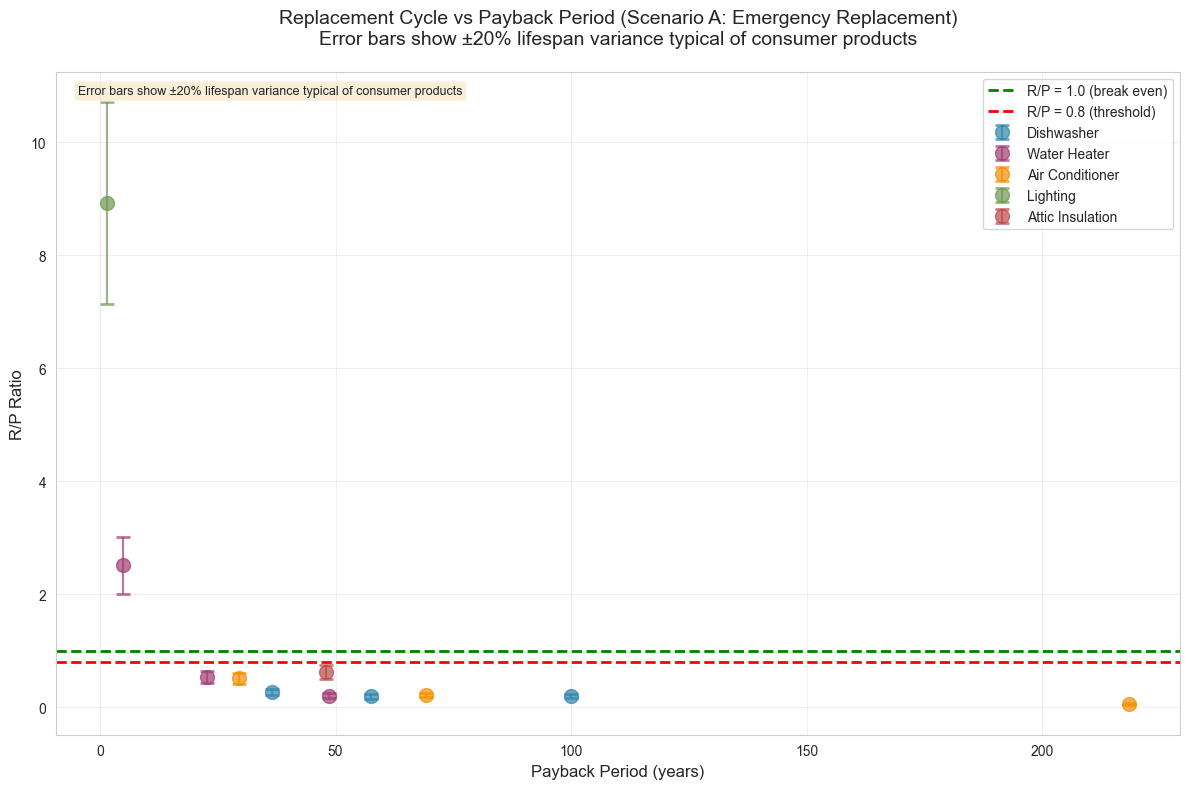

In [7]:
# R/P Ratio Scatter Plot with error bars
fig, ax = plt.subplots(figsize=(12, 8))

# Color map for categories
category_colors = {
    'Dishwasher': '#2E86AB',
    'Water Heater': '#A23B72',
    'Air Conditioner': '#F18F01',
    'Lighting': '#6A994E',
    'Attic Insulation': '#BC4749'
}

# Plot systems with error bars
for category in df['category'].unique():
    category_data = df[df['category'] == category]
    
    # Convert to numpy arrays to avoid FutureWarning with single-element Series
    payback = category_data['payback_period'].values
    rp_ratio = category_data['rp_ratio_scenario_a'].values
    rp_low = category_data['rp_ratio_low'].values
    rp_high = category_data['rp_ratio_high'].values
    
    # Calculate error bar ranges
    yerr_lower = rp_ratio - rp_low
    yerr_upper = rp_high - rp_ratio
    
    ax.errorbar(
        payback, 
        rp_ratio,
        yerr=[yerr_lower, yerr_upper],
        fmt='o',
        label=category,
        color=category_colors[category],
        markersize=10,
        alpha=0.7,
        capsize=5,
        capthick=2
    )

# Threshold lines
ax.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='R/P = 1.0 (break even)')
ax.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='R/P = 0.8 (threshold)')

ax.set_xlabel('Payback Period (years)', fontsize=12)
ax.set_ylabel('R/P Ratio', fontsize=12)
ax.set_title('Replacement Cycle vs Payback Period (Scenario A: Emergency Replacement)\nError bars show ±20% lifespan variance typical of consumer products', 
             fontsize=14, pad=20)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add note
ax.text(0.02, 0.98, 'Error bars show ±20% lifespan variance typical of consumer products', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()



## 2. Comfort Gap Visualization

Bar chart showing comfort gap for environmental utilities.



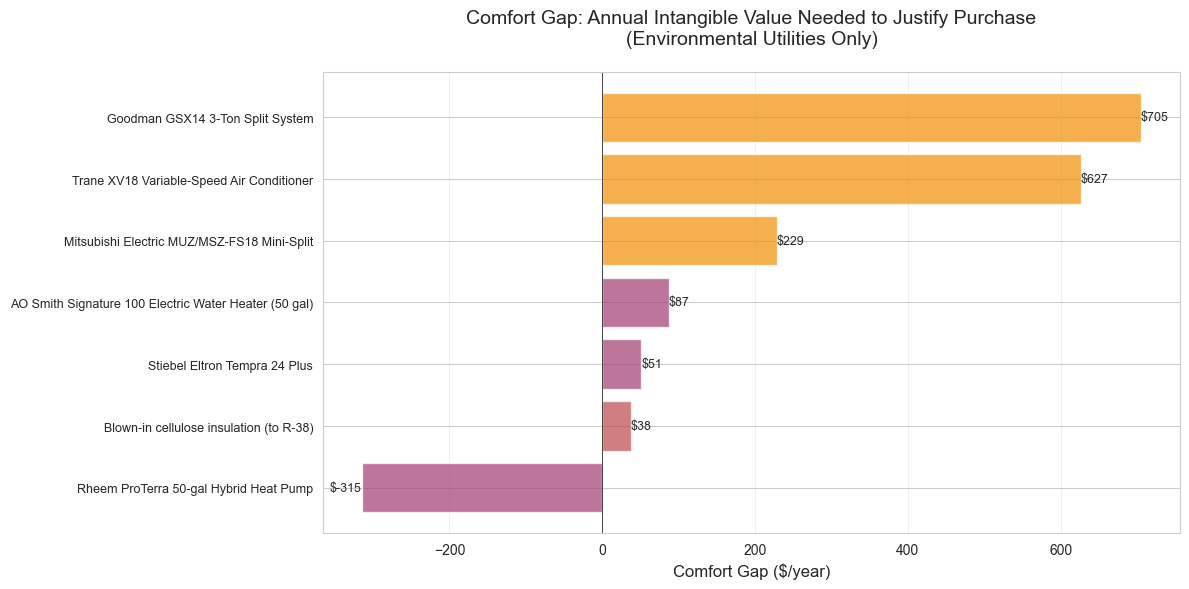


Visualization shows 7 environmental utilities.
Comfort gap represents the annual intangible value (comfort, health, ambient conditions)
needed beyond energy savings to financially justify purchase.


In [8]:
# Comfort Gap Bar Chart: Annual Intangible Value Needed to Justify Purchase
# Filter to environmental utilities only
comfort_categories = ['Water Heater', 'Air Conditioner', 'Attic Insulation']
comfort_mask = df['category'].isin(comfort_categories)
environmental_utilities = df[comfort_mask].copy()

if len(environmental_utilities) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Sort by comfort gap
    environmental_utilities_sorted = environmental_utilities.sort_values('comfort_gap', ascending=True)
    
    # Create bar chart
    colors = ['#A23B72' if cat == 'Water Heater' else '#F18F01' if cat == 'Air Conditioner' else '#BC4749' 
              for cat in environmental_utilities_sorted['category']]
    
    bars = ax.barh(range(len(environmental_utilities_sorted)), 
                    environmental_utilities_sorted['comfort_gap'],
                    color=colors, alpha=0.7)
    
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_yticks(range(len(environmental_utilities_sorted)))
    ax.set_yticklabels(environmental_utilities_sorted['model'], fontsize=9)
    ax.set_xlabel('Comfort Gap ($/year)', fontsize=12)
    ax.set_title('Comfort Gap: Annual Intangible Value Needed to Justify Purchase\n(Environmental Utilities Only)', 
                 fontsize=14, pad=20)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (idx, row) in enumerate(environmental_utilities_sorted.iterrows()):
        ax.text(row['comfort_gap'], i, f"${row['comfort_gap']:,.0f}", 
                va='center', ha='right' if row['comfort_gap'] < 0 else 'left', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nVisualization shows {len(environmental_utilities)} environmental utilities.")
    print("Comfort gap represents the annual intangible value (comfort, health, ambient conditions)")
    print("needed beyond energy savings to financially justify purchase.")



## 3. Cash vs HELOC Comparison

Comparison of cash and HELOC financing over 30-year horizon.



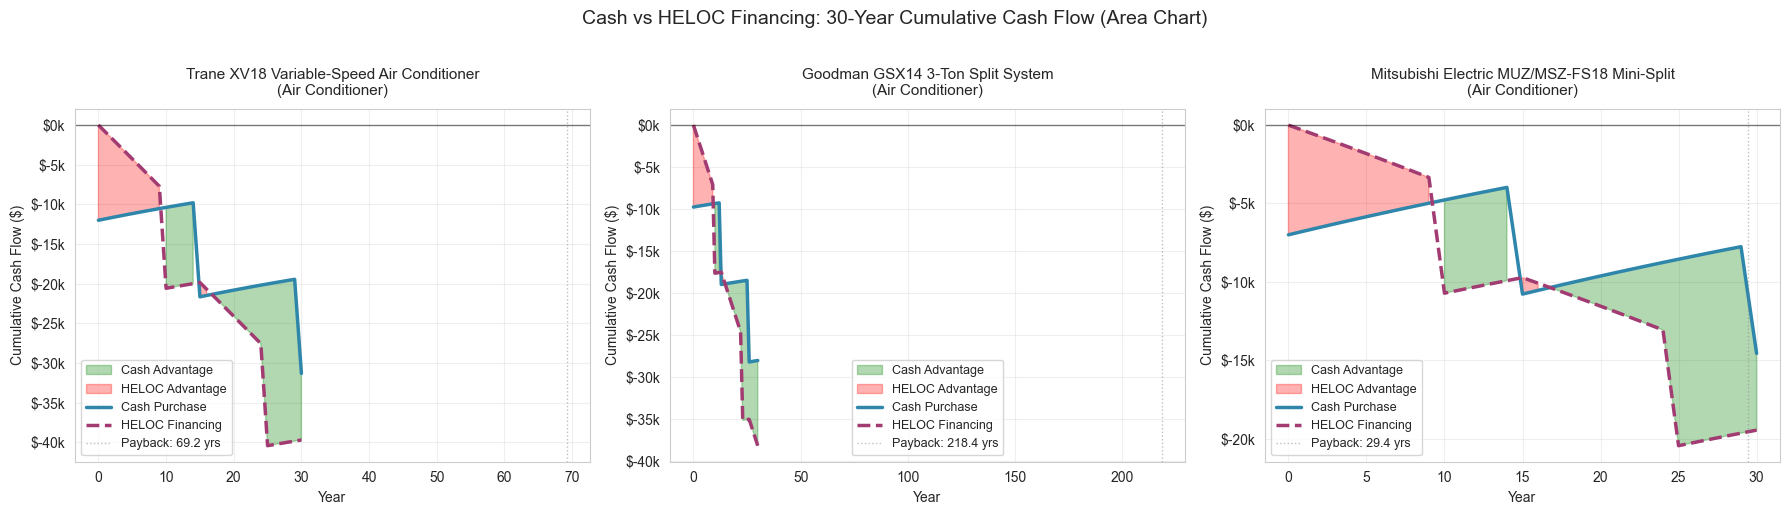

In [9]:
# Cash vs HELOC Comparison - Area Chart with Shaded Difference
# This visualization highlights the difference between cash and HELOC financing
# by shading the area between the two lines

from replacement_trap_utils import calculate_lifetime_value_cash, calculate_lifetime_value_heloc
from replacement_trap_config import HELOC_RATE, HELOC_LOAN_TERM, TIME_HORIZON, EFFICIENCY_DEGRADATION_RATE

# Select a few representative systems for visualization
representative_systems = df.nlargest(3, 'installed_cost')  # Top 3 by cost

fig, axes = plt.subplots(1, len(representative_systems), figsize=(18, 5))
if len(representative_systems) == 1:
    axes = [axes]

for idx, (sys_idx, system) in enumerate(representative_systems.iterrows()):
    ax = axes[idx]
    
    # Calculate cash flow
    cash_flow, _ = calculate_lifetime_value_cash(
        system['installed_cost'],
        system['annual_savings'],
        system['lifespan_years'],
        horizon=TIME_HORIZON,
        degradation_rate=EFFICIENCY_DEGRADATION_RATE
    )
    
    # Calculate HELOC flow
    heloc_flow, _ = calculate_lifetime_value_heloc(
        system['installed_cost'],
        system['annual_savings'],
        system['lifespan_years'],
        rate=HELOC_RATE,
        loan_term=HELOC_LOAN_TERM,
        horizon=TIME_HORIZON,
        degradation_rate=EFFICIENCY_DEGRADATION_RATE
    )
    
    years = np.arange(TIME_HORIZON + 1)
    
    # Fill area between the two lines to show the difference
    # Green where cash is better (higher), red where HELOC is better
    ax.fill_between(years, cash_flow, heloc_flow, 
                     where=(cash_flow >= heloc_flow), 
                     alpha=0.3, color='green', label='Cash Advantage')
    ax.fill_between(years, cash_flow, heloc_flow, 
                     where=(cash_flow < heloc_flow), 
                     alpha=0.3, color='red', label='HELOC Advantage')
    
    # Plot the lines
    ax.plot(years, cash_flow, label='Cash Purchase', linewidth=2.5, color='#2E86AB')
    ax.plot(years, heloc_flow, label='HELOC Financing', linewidth=2.5, color='#A23B72', linestyle='--')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Convert to float safely (handles both scalar and Series)
    payback_val = system['payback_period']
    payback_period_val = float(payback_val.iloc[0] if isinstance(payback_val, pd.Series) else payback_val)
    if payback_period_val != np.inf:
        ax.axvline(x=payback_period_val, color='gray', linestyle=':', linewidth=1, alpha=0.5, 
                   label=f'Payback: {payback_period_val:.1f} yrs')
    
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Cumulative Cash Flow ($)', fontsize=10)
    ax.set_title(f'{system["model"]}\n({system["category"]})', fontsize=11, pad=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))

plt.suptitle('Cash vs HELOC Financing: 30-Year Cumulative Cash Flow (Area Chart)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
